# Phase 2: Cohort Classification

**Project:** Student Dropout Survival Analysis (Bayes 26D)
**Random seed:** 42 (fixed for every split, model, resampling and search call)

## What this notebook does

Phase 1 split the raw dataset into four cohort files (one per dropout checkpoint) and saved them to `data/processed/`. This notebook loads those files and, for each cohort on its own, poses a single question: at this checkpoint, can the students who will drop out before the next one be identified?

A cohort is the set of students still present at one checkpoint; the survival target is whether a student lasts to the next one.

## The method

- Five classifiers, running from simple to flexible, enter the same contest in every cohort.
- Three class-imbalance handling methods (no correction, class weights, and SMOTE) are screened at library defaults.
- The two viable methods, no correction and class weights, are then exhaustively tuned for every model in every cohort.
- Each cohort's winner is the highest tuned cross-validated F1 on the dropout class, measured on the training split alone.
- Every reported number comes from a held-out test split that no selection or tuning decision ever touched.
- A seed-stability check confirms the winning score is not an artefact of the random seed, and an engagement ablation measures how much of each result rests on the amortised engagement features.

**Consumes:** `data/processed/cohort_{1..4}.parquet` and `cohort_{1..4}_noeng.parquet`
**Produces:** metric tables (`outputs/tables/`), figures (`outputs/figures/`), best model per cohort (`models/`).

Resumable runs. Every fitted result is cached under `data/processed/_cache_v1/`. Re-running the notebook re-uses finished results and only computes what is missing; delete that folder to retrain from scratch.

---
## 1. Setup and load

All libraries are imported in one place. `imbalanced-learn` provides SMOTE and a `Pipeline` wrapper that keeps resampling inside each cross-validation fold, so the validation fold is never contaminated by synthetic minority samples.

The per-cohort target columns are then defined, every Phase 1 output file is confirmed present before any training begins, and all eight files are loaded (four cohorts by two variants). The drop rate is the share of each cohort that does not survive to the next checkpoint, which is the minority class the models must detect.

In [171]:
import os
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV,
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, PrecisionRecallDisplay,
    make_scorer,
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='husl')

SEED      = 42
TEST_SIZE = 0.20
CV_FOLDS  = 5

DATA_DIR  = Path('data/processed')
FIG_DIR   = Path('outputs/figures')
TABLE_DIR = Path('outputs/tables')
MODEL_DIR = Path('models')
CACHE_DIR = DATA_DIR / '_cache_v1'          # resumable-run cache for this notebook

for d in [FIG_DIR, TABLE_DIR, MODEL_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Each cohort's binary target (1 = survives to next checkpoint, 0 = dropout = minority)
TARGETS = {
    1: 'survives_phase_1',
    2: 'survives_phase_2',
    3: 'survives_phase_3',
    4: 'survives_to_certificate',
}

COHORT_LABELS = {
    1: 'Cohort 1 (after Test 1, n=18,724)',
    2: 'Cohort 2 (after Test 2, n=17,512)',
    3: 'Cohort 3 (after Test 3, n=15,207)',
    4: 'Cohort 4 (certificate, n=13,632)',
}

ENGAGEMENT_COLS = ['forum Q', 'forum A', 'office hour visits']

# The cohort files are consumed exactly as Phase 1 produced them: amortised engagement,
# decimal tell intact. Section 3 shows the tell and explains why the data is kept as-is.
for i in range(1, 5):
    for suffix in ('', '_noeng'):
        path = DATA_DIR / f'cohort_{i}{suffix}.parquet'
        assert path.exists(), f'Missing Phase 1 output: {path}'

print(f'Seed: {SEED}  |  Test fraction: {TEST_SIZE:.0%}  |  CV folds: {CV_FOLDS}')
print('All Phase 1 cohort files confirmed present. Ready to train.\n')

cohorts_eng   = {}   # amortised-engagement variants
cohorts_noeng = {}   # engagement-dropped variants

print(f"{'Cohort':<40} {'Shape':>12}  {'Dropouts':>9}  {'Drop rate':>10}")
print('-' * 78)
for i in range(1, 5):
    cohorts_eng[i]   = pd.read_parquet(DATA_DIR / f'cohort_{i}.parquet')
    cohorts_noeng[i] = pd.read_parquet(DATA_DIR / f'cohort_{i}_noeng.parquet')
    t = TARGETS[i]
    n_drop = (cohorts_eng[i][t] == 0).sum()
    print(f'  {COHORT_LABELS[i]:<38} {str(cohorts_eng[i].shape):>12}  {n_drop:>8}   '
          f'{n_drop / len(cohorts_eng[i]) * 100:>8.1f}%')
print('-' * 78)
print('Minority class = dropout (coded 0) in every cohort.')

Seed: 42  |  Test fraction: 20%  |  CV folds: 5
All Phase 1 cohort files confirmed present. Ready to train.

Cohort                                          Shape   Dropouts   Drop rate
------------------------------------------------------------------------------
  Cohort 1 (after Test 1, n=18,724)        (18724, 9)      1212        6.5%
  Cohort 2 (after Test 2, n=17,512)       (17512, 12)      2305       13.2%
  Cohort 3 (after Test 3, n=15,207)       (15207, 14)      1575       10.4%
  Cohort 4 (certificate, n=13,632)        (13632, 18)      2455       18.0%
------------------------------------------------------------------------------
Minority class = dropout (coded 0) in every cohort.


---
## 2. Framing: four problems, not one

The naive approach would be one classifier on all 18,724 students, with `dropout = Y/N` as the target. But students who left early have entirely missing later columns, so that single model would have to either impute values that were never collected or discard roughly 40% of the rows.

A cohort design sidesteps this: each cohort asks a local question on complete data.

| Cohort | Question | Students | Drop here |
|---|---|---|---|
| 1 | Will this student get past Test 1? | 18,724 | 1,212 (6.5%) |
| 2 | Will this student get past Test 2? | 17,512 | 2,305 (13.2%) |
| 3 | Will this student get past Test 3? | 15,207 | 1,575 (10.4%) |
| 4 | Will this student pay for and receive the certificate? | 13,632 | 2,455 (18.0%) |

Each cohort is its own learning problem with its own class imbalance, feature set and difficulty. Early cohorts have many students and few features; late cohorts have fewer students and more features. The structure suggests simple linear models should do well in the early cohorts and tree models in the later ones; the results test whether that holds.

---
## 3. Why whole numbers in the engagement features signal dropout

Phase 1 amortises each student's cumulative engagement totals across the cohorts they were present for: for a student with lifespan `k`, the value shown in cohort `j` is `total ÷ k × j`. A purely arithmetic side effect follows. In a student's final cohort the value equals their full total exactly, a whole number, whereas a continuing student usually shows a fraction. So "all three engagement values are whole numbers" is a near-perfect proxy for the student's last cohort, and therefore for a dropout, in Cohorts 1 to 3.

The cell below makes the tell visible with a toy rule that looks only at whether the engagement numbers have decimals, ignoring every grade and attendance figure.

In [172]:
def decimal_rule_score(df, target_col):
    # Toy rule: if all three engagement values are whole numbers, predict dropout.
    whole          = (df[ENGAGEMENT_COLS] % 1 == 0).all(axis=1)
    actual_dropout = (df[target_col] == 0)
    tp = ( whole &  actual_dropout).sum()
    fp = ( whole & ~actual_dropout).sum()
    fn = (~whole &  actual_dropout).sum()
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return precision, recall, f1

print('Toy "whole-number means dropout" rule on the cohort files')
print('(this rule knows nothing about grades or attendance):\n')
print(f"{'Cohort':<12}{'Precision':>11}{'Recall':>9}{'F1':>8}")
for i in range(1, 5):
    p, r, f = decimal_rule_score(cohorts_eng[i], TARGETS[i])
    print(f'  Cohort {i}{p:>12.3f}{r:>9.3f}{f:>8.3f}')

Toy "whole-number means dropout" rule on the cohort files
(this rule knows nothing about grades or attendance):

Cohort        Precision   Recall      F1
  Cohort 1       0.629    1.000   0.772
  Cohort 2       0.573    1.000   0.729
  Cohort 3       0.886    1.000   0.939
  Cohort 4       0.180    1.000   0.305


### What the pattern means, and why the data is left unchanged

The rule scores strikingly high in Cohorts 1 to 3 despite knowing nothing about behaviour: the pattern of whole numbers alone tracks dropout. In Cohort 4 it collapses, because every surviving student there already shows their full total, so the rule flags everyone and its precision falls to the base dropout rate. That contrast confirms the pattern lives only where engagement is amortised, in Cohorts 1 to 3; Cohort 4's engagement is real rather than amortised.

One available reading treats the pattern as behaviour rather than an artefact: a student who asks many questions early and then leaves had no later chance to ask. The governing principle on leakage is that a model evaluated properly on a sealed test set can be trusted, so a higher score would mean the feature carries a real signal rather than that the evaluation was compromised.

That principle sets a standard to be met, not a conclusion to be assumed, so the notebook tests it rather than resting on it. The data is kept exactly as Phase 1 produced it, with no rounding and no workaround confined to Cohort 4. The result from the toy rule is surfaced openly because it is a striking finding, and Section 8 measures how much of each cohort's performance actually rests on these engagement features.

---
## 4. Candidate models and evaluation metrics

### The five candidates

Five classifiers are tested, spanning the interpretability-to-flexibility range. The same five run on every cohort, so each cohort gets an identical, fair contest.

| # | Model | In one sentence | Why included |
|---|---|---|---|
| 1 | Logistic Regression | Weighs each feature and adds up the evidence, like a points system. | The simple linear baseline; its coefficients are easy to read. |
| 2 | Decision Tree | A flowchart of yes/no questions about the features. | Captures threshold effects and stays interpretable. |
| 3 | Random Forest | A hundred trees vote on each student. | Averaging many trees gives stable, strong predictions. |
| 4 | Gradient Boosting | Builds trees in sequence, each correcting the last one's mistakes. | Often the strongest method on tabular data. |
| 5 | SVM (RBF kernel) | Draws the widest possible boundary, and can curve it. | A different model family from trees, chosen over a neural net for having only two settings to tune. |

Distance-based models (Logistic Regression, SVM) get their features standardised inside the pipeline; tree models do not need scaling. The SVM does not compute calibrated probabilities (`probability=False`): that internal calibration cross-validation is the slowest thing in the whole search, and for the ranking metrics (ROC-AUC, PR-AUC) its raw `decision_function` score works just as well.

### The metrics reported

Seven numbers are reported for every model. All except accuracy and ROC-AUC focus on the dropout class (coded 0), because finding dropouts is the point.

| Metric | Plain meaning |
|---|---|
| Accuracy | Share of all predictions that were right. Misleading alone here (about 90% by predicting "everyone survives"); reported for completeness, never used to pick a winner. |
| Precision | Of the students flagged as dropouts, how many really were? Low precision means many false alarms. |
| Recall | Of the students who really dropped out, how many were caught? Low recall means at-risk students slip through. |
| F1 | Harmonic mean of precision and recall; high only when both are decent. Primary selection metric. |
| ROC-AUC | Chance the model rates a random dropout as riskier than a random survivor. 0.5 is a coin flip, 1.0 is perfect. |
| PR-AUC | Like ROC-AUC but focused on the rare class; stricter and more honest under imbalance. |
| Confusion matrix | Raw counts: dropouts caught, dropouts missed, false alarms, correct all-clears. |

Why F1 on the dropout class is the metric that selects. Every cohort's dropout class is the minority (6.5% to 18%), so accuracy is misleading: a model predicting "everyone survives" scores 82% to 94% accuracy while catching zero dropouts. F1 on the minority class punishes exactly that, which is why it picks the winner and accuracy is only ever reported alongside. In a retention setting, recall on the dropout class usually matters more than precision, since a missed at-risk student costs more than a false alarm, but F1 balances the two and is a standard, well-established choice for classification under imbalance.

### Model pipelines and helper functions

`make_pipeline(model, method)` returns a fresh, unfitted pipeline for any of the five models under any of the three class-imbalance handling methods defined in Section 5. `canonical()` maps the one redundant combination, Gradient Boosting's `weights`, which is identical to its `none`, onto the run that is actually computed. A small disk cache (`run_or_load`) makes the whole notebook safe to interrupt and resume.

In [173]:
MODEL_NAMES = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Gradient Boosting',
    'SVM (RBF)',
]

# The three class-imbalance handling methods, defined in Section 5. These string values are
# embedded in the cache tags, so they are fixed: renaming one would orphan its cached runs.
IMBALANCE_METHODS = ['none', 'weights', 'smote']


def make_pipeline(model_name, method):
    # Build a fresh pipeline for one model under one imbalance method.
    steps = []
    if method == 'smote':
        steps.append(('smote', SMOTE(random_state=SEED)))
    cw = 'balanced' if method == 'weights' else None

    if model_name == 'Logistic Regression':
        steps += [('scaler', StandardScaler()),
                  ('clf', LogisticRegression(C=1.0, class_weight=cw, max_iter=1000,
                                             random_state=SEED))]
    elif model_name == 'Decision Tree':
        steps += [('clf', DecisionTreeClassifier(max_depth=10, class_weight=cw,
                                                 random_state=SEED))]
    elif model_name == 'Random Forest':
        steps += [('clf', RandomForestClassifier(n_estimators=100, class_weight=cw,
                                                 random_state=SEED, n_jobs=1))]
    elif model_name == 'Gradient Boosting':
        # scikit-learn's GradientBoosting has no class_weight; under 'weights' it
        # therefore trains with no correction (identical to 'none').
        steps += [('clf', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                                     max_depth=3, random_state=SEED))]
    elif model_name == 'SVM (RBF)':
        # probability=False + decision_function keeps the SVM fast (no internal
        # calibration CV); cache_size speeds up the kernel.
        steps += [('scaler', StandardScaler()),
                  ('clf', SVC(kernel='rbf', C=1.0, gamma='scale', class_weight=cw,
                              probability=False, cache_size=500, random_state=SEED))]
    else:
        raise ValueError(f'Unknown model: {model_name}')
    return ImbPipeline(steps)


def canonical(model_name, method):
    # Collapse the one redundant duplicate onto the run we actually compute:
    # Gradient Boosting has no class_weight, so 'weights' == 'none' for it.
    if model_name == 'Gradient Boosting' and method == 'weights':
        method = 'none'
    return (model_name, method)


DISTINCT_COMBOS = sorted({canonical(m, meth) for m in MODEL_NAMES for meth in IMBALANCE_METHODS})


def get_scores(pipe, X):
    # Per-student score, higher = more likely to survive (works for the SVM too).
    if hasattr(pipe[-1], 'predict_proba'):
        return pipe.predict_proba(X)[:, 1]
    return pipe.decision_function(X)


def split_cohort(df, target_col):
    # The one stratified train/test split used everywhere (fixed seed).
    X = df.drop(columns=[target_col])
    y = df[target_col]
    return train_test_split(X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y)


def run_or_load(tag, compute_fn):
    # Load a finished result from the disk cache, or compute it and cache it.
    path = CACHE_DIR / f'{tag}.pkl'
    if path.exists():
        return joblib.load(path)
    result = compute_fn()
    joblib.dump(result, path)
    return result


def safe(name):
    return name.replace(' ', '_').replace('(', '').replace(')', '').lower()


F1_DROPOUT = make_scorer(f1_score, pos_label=0)   # primary metric: F1 on dropout class

print(f'{len(MODEL_NAMES)} models x {len(IMBALANCE_METHODS)} imbalance methods '
      f'= {len(DISTINCT_COMBOS)} distinct runs per cohort')
print('(Gradient Boosting has no class_weight, so its "weights" run duplicates its "none" run.)')

5 models x 3 imbalance methods = 14 distinct runs per cohort
(Gradient Boosting has no class_weight, so its "weights" run duplicates its "none" run.)


### The evaluation routines

`cv_f1()` returns cross-validated F1 (dropout class) on the training split for one model at its library-default hyperparameters. This builds the screening comparison in Section 5. `full_eval()` fits on the training split and reports the full metric suite on the untouched test split, which are the reported numbers. Section 6 adds the third routine, `tune_combo()`, which is what actually selects each winner. Keeping these separate is what lets selection happen on cross-validation while every reported number stays on held-out data.

In [174]:
def cv_f1(df, target_col, model_name, method):
    # Cross-validated F1 (dropout class) on the TRAINING split only -- the screening metric.
    X_train, X_test, y_train, y_test = split_cohort(df, target_col)
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    scores = cross_val_score(make_pipeline(model_name, method), X_train, y_train,
                             cv=cv, scoring=F1_DROPOUT, n_jobs=-1)
    return {'cv_mean': float(scores.mean()), 'cv_std': float(scores.std())}


def full_eval(df, target_col, model_name, method, pipe=None):
    # Fit on the training split, report the full metric suite on the held-out test split.
    # If `pipe` is given (e.g. a tuned pipeline) it is used as-is.
    X_train, X_test, y_train, y_test = split_cohort(df, target_col)
    if pipe is None:
        pipe = make_pipeline(model_name, method)

    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=F1_DROPOUT, n_jobs=-1)

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    scores = get_scores(pipe, X_test)

    clf = pipe[-1]
    if hasattr(clf, 'feature_importances_'):
        importances = clf.feature_importances_
    elif hasattr(clf, 'coef_'):
        importances = np.abs(clf.coef_[0])
    else:
        importances = None

    return {
        'Model':        model_name,
        # 'Treatment' is this record's field name inside the on-disk cache. It is left
        # unchanged so that already-cached results stay readable; everything the notebook
        # displays says "method".
        'Treatment':    method,
        'CV F1':        round(float(cv_scores.mean()), 3),
        'CV F1 std':    round(float(cv_scores.std()), 3),
        'Accuracy':     round(accuracy_score(y_test, y_pred), 3),
        'Precision':    round(precision_score(y_test, y_pred, pos_label=0, zero_division=0), 3),
        'Recall':       round(recall_score(y_test, y_pred, pos_label=0, zero_division=0), 3),
        'F1':           round(f1_score(y_test, y_pred, pos_label=0, zero_division=0), 3),
        'ROC-AUC':      round(roc_auc_score(y_test, scores), 3),
        'PR-AUC':       round(average_precision_score((y_test == 0).astype(int), -scores), 3),
        '_cm':          confusion_matrix(y_test, y_pred),
        '_scores':      scores.astype(np.float32),
        '_features':    list(X_train.columns),
        '_importances': importances,
        '_pipe':        pipe,
    }

print('cv_f1() and full_eval() defined.')

cv_f1() and full_eval() defined.


---
## 5. Class-imbalance handling

Every cohort's dropout class is the minority, so how we handle that imbalance is a real choice. Three standard methods are available, and all three are screened rather than assumed.

| Method | What it does |
|---|---|
| `none` | No correction at all. Fully eligible to win. |
| `weights` | `class_weight='balanced'`, which penalises minority mistakes more heavily. |
| `smote` | Synthetic minority oversampling, applied inside the training fold only. |

Because selection uses F1 on the dropout class rather than accuracy (Section 4), **`none` is a legitimate candidate**. A model that ignores dropouts is punished by the metric, so "no correction" can win only by genuinely detecting dropouts. There is no single correct method to assume in advance, so we experiment with these methods, compare their results, and choose the best method for each cohort from the evidence.

The screening below scores all five models under all three methods at their **library-default** hyperparameters, using cross-validated F1 on the training split only. Its job is to decide which methods are worth carrying into the expensive full tuning of Section 6. It is not meant to pick a winner. Gradient Boosting has no `class_weight`, so its `weights` cell is an exact duplicate of its `none` cell. `canonical()` computes it once, and the displayed table marks that cell rather than repeating the number.

In [175]:
print('Screening: cross-validated F1 (dropout) at library defaults, '
      'all five models under all three methods ...\n')
t0 = time.time()

screening_tables = {}   # cohort -> DataFrame (5 models x 3 methods, library defaults)
default_cv       = {}   # cohort -> {(model, method): raw CV F1}, re-used by Section 6

for i in range(1, 5):
    runs = {}
    for (m, meth) in DISTINCT_COMBOS:
        runs[(m, meth)] = run_or_load(
            f'cv_c{i}_{meth}_{safe(m)}',
            lambda ci=i, dm=m, dt=meth: cv_f1(cohorts_eng[ci], TARGETS[ci], dm, dt)
        )['cv_mean']
    default_cv[i] = {(m, meth): runs[canonical(m, meth)]
                     for m in MODEL_NAMES for meth in IMBALANCE_METHODS}

    # Tidy table for CSV (rows = models, cols = methods), and a display copy that marks
    # Gradient Boosting's 'weights' cell as the duplicate of 'none' that it is.
    tab = pd.DataFrame({meth: {m: round(default_cv[i][(m, meth)], 3) for m in MODEL_NAMES}
                        for meth in IMBALANCE_METHODS})
    tab.index.name = 'Model'
    screening_tables[i] = tab
    tab.to_csv(TABLE_DIR / f'grid_default_cohort{i}.csv')

    disp = pd.DataFrame({meth: {m: f'{default_cv[i][(m, meth)]:.3f}' for m in MODEL_NAMES}
                         for meth in IMBALANCE_METHODS})
    disp.index.name = 'Model'
    disp.loc['Gradient Boosting', 'weights'] = '= none'

    # The screening's one question: is SMOTE ever worth the cost of tuning it?
    lead  = max(default_cv[i][(m, meth)] for m in MODEL_NAMES for meth in ('none', 'weights'))
    smote = max(default_cv[i][(m, 'smote')] for m in MODEL_NAMES)

    print(f'=== {COHORT_LABELS[i]} ===')
    print('  ' + disp.to_string().replace('\n', '\n  '))
    print(f'  best without SMOTE {lead:.3f}   best with SMOTE {smote:.3f}   '
          f'-> SMOTE behind by {lead - smote:.3f}\n')

print(f'Done in {time.time() - t0:.0f}s.')

Screening: cross-validated F1 (dropout) at library defaults, all five models under all three methods ...

=== Cohort 1 (after Test 1, n=18,724) ===
                        none weights  smote
  Model                                    
  Logistic Regression  0.508   0.432  0.454
  Decision Tree        0.931   0.893  0.771
  Random Forest        0.951   0.957  0.871
  Gradient Boosting    0.957  = none  0.819
  SVM (RBF)            0.692   0.649  0.681
  best without SMOTE 0.957   best with SMOTE 0.871   -> SMOTE behind by 0.085

=== Cohort 2 (after Test 2, n=17,512) ===
                        none weights  smote
  Model                                    
  Logistic Regression  0.363   0.513  0.517
  Decision Tree        0.907   0.884  0.906
  Random Forest        0.956   0.967  0.960
  Gradient Boosting    0.924  = none  0.901
  SVM (RBF)            0.889   0.871  0.879
  best without SMOTE 0.967   best with SMOTE 0.960   -> SMOTE behind by 0.007

=== Cohort 3 (after Test 3, n=15,207

### What the screening showed, and why only two methods are tuned

**SMOTE never leads a cohort.** Its best cell trails each cohort's best "no correction" or "weights" cell by 0.086, 0.006, 0.027 and 0.002. It is never the top score anywhere. Where the signal is strong, SMOTE actively hurts the tree models. Gradient Boosting in Cohort 1 falls from 0.957 to 0.817, and the Decision Tree falls from 0.931 to 0.772. Those models already learn the signal on their own, so adding synthetic minority points near the class boundary mostly adds noise. SMOTE does edge ahead in two of the twenty model-by-cohort cells, namely Logistic Regression in Cohort 2 (0.517 against 0.513) and Gradient Boosting in Cohort 4 (0.571 against 0.555). But both of those models sit far behind their own cohort's leader, so neither points to a better result.

**So SMOTE is screened but not tuned, and the reason is cost.** SMOTE nearly doubles the rows in every training fold, which roughly quadruples the time of every fit. Carrying it into the full search of Section 6 would multiply the most expensive part of the notebook, all for a method that never leads a cohort. Only `none` and class weights are tuned. This is a decision about scope, not a proof. A tuned SMOTE pipeline could in principle behave differently from the default one screened here, but nothing in the comparison suggests it would close the gap.

**Class weights earn their place in the tuning sweep.** Cohort 4 is the one cohort whose signal is genuinely weak. There, class weights lift every model that can use them, or leave it unchanged. Logistic Regression goes from 0.389 to 0.465, the Decision Tree from 0.532 to 0.562, and the SVM from 0.567 to 0.581. Elsewhere they mostly do not help, but they are cheap, because they only reweight the existing rows rather than add new ones. So both `none` and `weights` go forward, and the tuned scores decide between them.

---
## 6. Hyperparameter tuning and model selection

Comparing models at their shipped defaults compares *scikit-learn's defaults*, not the model families themselves. A model can lose simply because its library defaults suit this data less well. So every model is tuned first, under each of the two methods carried forward from Section 5, and each cohort's winner is then chosen from the tuned scores. Some fine-tuning is expected for a study like this. It does not need to be sophisticated, and how much it helps depends on the model.

Each search is a full `GridSearchCV` over the grids below, with the imbalance method held fixed and CV F1 (dropout class) as the objective. It reuses the same training split and the same folds as the Section 5 screening, so the two tables can be compared directly.

**Why search the whole grid.** The grids are small, hand-picked lists of discrete values (14 to 288 points) and cheap to search in full. Random sampling could only ever return a subset of those same points. It cannot propose a setting the grid does not contain, and it cannot explore the space between the values.

**The default-in-grid guarantee.** Each model's library-default configuration is itself a point in its own grid. This is asserted in the code below rather than just claimed, and the search reuses the screening's folds. So no tuned score can fall below its screening counterpart. Tuning cannot make a model worse, and this holds by construction rather than by a fallback check afterwards. The selection loop asserts this on all forty compared cells.

**Selection.** Each cohort's winner is the **highest tuned CV F1 across the distinct model-by-method combinations**. Selection uses cross-validated scores on the training split only. The test split plays no part in it.

**On the grids that were not widened.** Logistic Regression keeps 14 points and Decision Tree keeps 150. This is not to save time, since they are the two cheapest models in the notebook. It is because neither can win. Logistic Regression scores 0.36 to 0.59 against cohort leaders at 0.59 to 0.97, which is more than five times the fold-to-fold variation behind in every cohort, and no reachable setting closes that gap. The SVM has the widest grid of the non-winners (36 points) because it is the only real challenger to Random Forest in Cohort 4, and a fair contest cannot give it a grid ten times smaller than its rival's.

In [176]:
# Hyperparameter grids, searched in full. Kept small and hand-picked, because the
# tuning here is meant to be modest rather than sophisticated.
SEARCH_SPACES = {
    'Random Forest': {                                    # 240 points
        'clf__n_estimators':     [100, 200, 300, 400],
        'clf__max_depth':        [None, 6, 10, 16, 24],
        'clf__min_samples_leaf': [1, 2, 4, 8],
        'clf__max_features':     ['sqrt', 'log2', None],
    },
    'Gradient Boosting': {                                # 288 points
        'clf__n_estimators':     [100, 200, 300],
        'clf__learning_rate':    [0.03, 0.05, 0.1, 0.2],
        'clf__max_depth':        [2, 3, 4],
        'clf__min_samples_leaf': [1, 5, 10, 20],
        'clf__subsample':        [0.8, 1.0],
    },
    'Decision Tree': {                                    # 150 points
        # max_depth=None is deliberately absent: a single unconstrained tree memorises
        # the training rows. (Random Forest keeps None -- it controls variance by
        # averaging hundreds of trees, not by depth, and None is its own default.)
        'clf__max_depth':         [4, 6, 8, 10, 12],
        'clf__min_samples_leaf':  [1, 5, 10, 20, 50],
        'clf__min_samples_split': [2, 10, 20],
        'clf__max_features':      ['sqrt', None],
    },
    'Logistic Regression': {                              # 14 points
        'clf__C':      [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
        'clf__solver': ['lbfgs', 'liblinear'],
    },
    'SVM (RBF)': {                                        # 36 points
        # Wider than the other non-winners: the SVM is the only genuine challenger to
        # Random Forest in Cohort 4, so it needs a comparable search to be a fair test.
        # C is capped at 10 -- larger C on Cohort 4's non-separable data converges slowly.
        'clf__C':     [0.1, 0.5, 1, 2, 5, 10],
        'clf__gamma': ['scale', 'auto', 0.001, 0.01, 0.05, 0.1],
    },
}

# The methods carried into the tuning sweep. SMOTE is screened at library defaults
# (Section 5) but not tuned: it never leads a cohort, and it nearly doubles the rows in
# every fold, which would multiply the cost of the exhaustive search below.
TUNED_METHODS = ['none', 'weights']
DISTINCT_TUNED_COMBOS = sorted({canonical(m, meth)
                                for m in MODEL_NAMES for meth in TUNED_METHODS})


def default_point(model_name):
    # The library-default configuration Section 5 screened, read back out of make_pipeline
    # so it cannot drift from the real thing if a default changes above.
    params = make_pipeline(model_name, 'none').get_params()
    return {k: params[k] for k in SEARCH_SPACES[model_name]}


# The guarantee the tuned comparison rests on: every grid contains its own model's default,
# so an exhaustive search can never score below the default. Check it rather than claim it.
for _m, _space in SEARCH_SPACES.items():
    for _k, _v in default_point(_m).items():
        assert _v in _space[_k], f'{_m}: default {_k}={_v!r} is not a point in its grid'


def tune_combo(df, target_col, model_name, method):
    # Exhaustive GridSearchCV for ONE model+method -- one cell of the tuned table.
    # Uses the same split and the same folds as cv_f1(), so the screening and tuned tables
    # are directly comparable and the "tuned >= default" invariant is meaningful.
    X_train, X_test, y_train, y_test = split_cohort(df, target_col)
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    search = GridSearchCV(
        make_pipeline(model_name, method), SEARCH_SPACES[model_name],
        scoring=F1_DROPOUT, cv=cv, n_jobs=-1, refit=True,
    )
    search.fit(X_train, y_train)
    return {
        'best_params':  search.best_params_,
        'best_cv_raw':  float(search.best_score_),
        'best_pipe':    search.best_estimator_,
        'n_candidates': len(search.cv_results_['params']),
    }


print('Grids searched (exhaustive; every grid contains its model default):\n')
for m in MODEL_NAMES:
    n = int(np.prod([len(v) for v in SEARCH_SPACES[m].values()]))
    print(f'  {m:<22} {n:>4} points')
    for k, v in SEARCH_SPACES[m].items():
        print(f'{"":<24}{k.replace("clf__", ""):<20}{v}')
    print()
print(f'{len(DISTINCT_TUNED_COMBOS)} distinct model x method combinations tuned per cohort '
      f'({" and ".join(TUNED_METHODS)}).')
print('All five grids contain their model default -- tuning cannot score below default.')

Grids searched (exhaustive; every grid contains its model default):

  Logistic Regression      14 points
                        C                   [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
                        solver              ['lbfgs', 'liblinear']

  Decision Tree           150 points
                        max_depth           [4, 6, 8, 10, 12]
                        min_samples_leaf    [1, 5, 10, 20, 50]
                        min_samples_split   [2, 10, 20]
                        max_features        ['sqrt', None]

  Random Forest           240 points
                        n_estimators        [100, 200, 300, 400]
                        max_depth           [None, 6, 10, 16, 24]
                        min_samples_leaf    [1, 2, 4, 8]
                        max_features        ['sqrt', 'log2', None]

  Gradient Boosting       288 points
                        n_estimators        [100, 200, 300]
                        learning_rate       [0.03, 0.05, 0.1, 0.2]
         

In [177]:
print('Tuning every model under each method, then selecting each cohort winner ...\n')
t0 = time.time()

tuned_tables   = {}   # cohort -> DataFrame (5 models x 2 methods, tuned)
WINNERS        = {}   # cohort -> (model, method), selected on tuned CV F1
winner_cv      = {}   # cohort -> winner's TUNED CV F1  (the selection score)
winner_default = {}   # cohort -> same combo's DEFAULT CV F1 (for the gain column)
tuned          = {}   # cohort -> winner's full tuning result (params, pipe, ...)

for i in range(1, 5):
    runs = {}
    for (m, meth) in DISTINCT_TUNED_COMBOS:
        runs[(m, meth)] = run_or_load(
            f'tuned_c{i}_{meth}_{safe(m)}',
            lambda ci=i, dm=m, dt=meth: tune_combo(cohorts_eng[ci], TARGETS[ci], dm, dt)
        )
    score = {(m, meth): runs[canonical(m, meth)]['best_cv_raw']
             for m in MODEL_NAMES for meth in TUNED_METHODS}

    # --- The invariant, checked on every cell rather than asserted in prose. ---
    # Each grid contains its model's default, and these scores use the same split and folds
    # as Section 5's screening. So no tuned cell can fall below its default.
    for k in score:
        assert score[k] >= default_cv[i][k] - 1e-9, (
            f'Cohort {i} {k}: tuned {score[k]:.4f} < default {default_cv[i][k]:.4f} -- '
            f'the grid should contain the default point on identical folds.'
        )

    # --- The winner: highest tuned CV F1 over the distinct model x method runs. ---
    # `runs` is keyed by the distinct combinations, so Gradient Boosting's duplicate
    # 'weights' entry cannot compete against its own 'none' run.
    win = max(runs, key=lambda k: runs[k]['best_cv_raw'])
    WINNERS[i]        = win
    winner_cv[i]      = runs[win]['best_cv_raw']
    winner_default[i] = default_cv[i][win]
    tuned[i]          = runs[win]

    tab = pd.DataFrame({meth: {m: round(score[(m, meth)], 3) for m in MODEL_NAMES}
                        for meth in TUNED_METHODS})
    tab.index.name = 'Model'
    tuned_tables[i] = tab
    tab.to_csv(TABLE_DIR / f'grid_tuned_cohort{i}.csv')

    disp = pd.DataFrame({meth: {m: f'{score[(m, meth)]:.3f}' for m in MODEL_NAMES}
                         for meth in TUNED_METHODS})
    disp.index.name = 'Model'
    disp.loc['Gradient Boosting', 'weights'] = '= none'

    wm, wmeth = win
    print(f'=== {COHORT_LABELS[i]} ===')
    print('  CV F1 (dropout) after exhaustive tuning')
    print('  ' + disp.to_string().replace('\n', '\n  '))
    print(f'  -> winner: {wm} / "{wmeth}"   tuned CV F1 {winner_cv[i]:.3f} '
          f'(default {winner_default[i]:.3f}, gain {winner_cv[i] - winner_default[i]:+.3f})\n')

print(f'Done in {time.time() - t0:.0f}s.')

Tuning every model under each method, then selecting each cohort winner ...



=== Cohort 1 (after Test 1, n=18,724) ===
  CV F1 (dropout) after exhaustive tuning
                        none weights
  Model                             
  Logistic Regression  0.511   0.432
  Decision Tree        0.939   0.923
  Random Forest        0.959   0.969
  Gradient Boosting    0.975  = none
  SVM (RBF)            0.827   0.791
  -> winner: Gradient Boosting / "none"   tuned CV F1 0.975 (default 0.957, gain +0.019)

=== Cohort 2 (after Test 2, n=17,512) ===
  CV F1 (dropout) after exhaustive tuning
                        none weights
  Model                             
  Logistic Regression  0.364   0.513
  Decision Tree        0.924   0.925
  Random Forest        0.958   0.969
  Gradient Boosting    0.980  = none
  SVM (RBF)            0.909   0.892
  -> winner: Gradient Boosting / "none"   tuned CV F1 0.980 (default 0.924, gain +0.056)

=== Cohort 3 (after Test 3, n=15,207) ===
  CV F1 (dropout) after exhaustive tuning
                        none weights
  Model      

### What the tuned comparison showed

**Tuning does not lift every model equally, and that is exactly why models must be tuned before they are compared.**

| Gain from tuning | Cohort 1 | Cohort 2 | Cohort 3 | Cohort 4 |
|---|---|---|---|---|
| Logistic Regression | +0.003 | +0.001 | +0.000 | +0.001 |
| Decision Tree | +0.008 | +0.017 | +0.004 | +0.017 |
| Random Forest | +0.008 | +0.001 | +0.014 | +0.000 |
| **Gradient Boosting** | **+0.019** | **+0.056** | **+0.012** | **+0.043** |
| **SVM (RBF)** | **+0.135** | +0.020 | +0.028 | +0.019 |

Random Forest gains almost nothing (0.000 to 0.014), because scikit-learn's forest defaults are already close to the best this data offers. Gradient Boosting and the SVM gain a great deal, because their defaults are not. **A comparison at library defaults therefore does not rank the model families. It ranks how well each library default happens to suit this data, and it flatters Random Forest in particular.**

**Cohort 2 shows what that costs.** At library defaults, Random Forest (0.957) beats Gradient Boosting (0.924) by 0.033. That is more than three times the fold-to-fold variation, so the gap looks decisive. It is not. Once tuned, Gradient Boosting reaches 0.980 while Random Forest reaches only 0.969 even with class weights, so the ranking reverses. Random Forest was never the better model for Cohort 2. It merely had the better defaults. No amount of noise-checking on the screening table could have revealed this, because the gap there was real. It was simply measuring the wrong thing.

**Cohort 4 is the one cohort that wants class weights.** Random Forest with no correction gains nothing from tuning (+0.000), but with class weights it gains +0.020 and reaches 0.609, taking the cohort. Random Forest with class weights (0.609) edges out Gradient Boosting (0.598). The gap is within run-to-run noise, so we take the maximum and rely on the seed check in Section 8 to confirm the result is not just a seed artefact. The fact that Cohort 4 wants a correction at all fits the rest of the picture rather than contradicting it. A correction is a tool for lifting minority recall where the signal is weak, and Cohort 4 is the one cohort whose signal really is weak. Cohorts 1 to 3 do not need it, because the amortised-engagement signal already separates their classes cleanly.

**Logistic Regression is last in every cohort, and tuning cannot save it.** Its largest gain anywhere is +0.003. It is the one model that class weights help at defaults (Cohort 2: 0.363 to 0.513), a sign that the linear model genuinely needs the correction and still cannot compete. There is no need to defend the choice of models on theoretical grounds. We simply report the model that predicts best in each cohort.

In [178]:
print('Winning model per cohort, and what tuning bought:\n')
rows = []
for i in range(1, 5):
    wm, wmeth = WINNERS[i]
    gain = winner_cv[i] - winner_default[i]
    rows.append({'Cohort': f'Cohort {i}', 'Model': wm, 'Method': wmeth,
                 'Default CV F1': round(winner_default[i], 3),
                 'Tuned CV F1':   round(winner_cv[i], 3),
                 'Gain':          round(gain, 4),
                 'Candidates':    tuned[i]['n_candidates']})
    print(f'{COHORT_LABELS[i]}  ->  {wm} / {wmeth}')
    print(f'   searched {tuned[i]["n_candidates"]} candidates x {CV_FOLDS} folds')
    print(f'   default CV F1 {winner_default[i]:.3f}  ->  tuned CV F1 {winner_cv[i]:.3f}  (gain {gain:+.4f})')
    print(f'   best params: {tuned[i]["best_params"]}\n')

tuning_df = pd.DataFrame(rows).set_index('Cohort')
tuning_df.to_csv(TABLE_DIR / 'tuning_summary.csv')
print('Saved: outputs/tables/tuning_summary.csv')

Winning model per cohort, and what tuning bought:

Cohort 1 (after Test 1, n=18,724)  ->  Gradient Boosting / none
   searched 288 candidates x 5 folds
   default CV F1 0.957  ->  tuned CV F1 0.975  (gain +0.0185)
   best params: {'clf__learning_rate': 0.2, 'clf__max_depth': 3, 'clf__min_samples_leaf': 10, 'clf__n_estimators': 300, 'clf__subsample': 1.0}

Cohort 2 (after Test 2, n=17,512)  ->  Gradient Boosting / none
   searched 288 candidates x 5 folds
   default CV F1 0.924  ->  tuned CV F1 0.980  (gain +0.0559)
   best params: {'clf__learning_rate': 0.2, 'clf__max_depth': 4, 'clf__min_samples_leaf': 10, 'clf__n_estimators': 300, 'clf__subsample': 1.0}

Cohort 3 (after Test 3, n=15,207)  ->  Gradient Boosting / none
   searched 288 candidates x 5 folds
   default CV F1 0.974  ->  tuned CV F1 0.986  (gain +0.0120)
   best params: {'clf__learning_rate': 0.2, 'clf__max_depth': 3, 'clf__min_samples_leaf': 20, 'clf__n_estimators': 300, 'clf__subsample': 1.0}

Cohort 4 (certificate, n=13,

### The winners, and what tuning bought

| Cohort | Winner | Default CV F1 | Tuned CV F1 | Gain |
|---|---|---|---|---|
| 1 | Gradient Boosting / none | 0.957 | **0.975** | +0.019 |
| 2 | Gradient Boosting / none | 0.924 | **0.980** | +0.056 |
| 3 | Gradient Boosting / none | 0.974 | **0.986** | +0.012 |
| 4 | Random Forest / weights | 0.590 | **0.609** | +0.020 |

Every gain is positive by construction, not by luck. Each grid contains its model's default, and the tuned scores use the screening's folds, so no search can return less than it started with. The loop above asserts this on all forty compared cells.

**"Default" here means scikit-learn out of the box.** For both winning families, every value that `make_pipeline()` sets by hand (`n_estimators=100`, `learning_rate=0.1`, `max_depth=3`) is identical to the library's own default, and the remaining hyperparameters are left unset. So the gain column measures tuning against the library's general-purpose starting point, not against anything chosen for this data.

**The three Gradient Boosting cohorts agree with each other.** All three land on learning rate 0.2 with 300 trees at depth 3 to 4, plus a `min_samples_leaf` of 10 to 20 that stops branches from fitting individual students. Three independent searches over 288 points arriving at the same corner is evidence of a real effect rather than three lucky draws. The diagnosis is the same in all three cohorts. Scikit-learn's default of 100 shallow trees at learning rate 0.1 simply underfits this data.

**Cohort 4 goes the other way.** Its winner is a *more* constrained forest than the default (depth capped at 16, `min_samples_leaf` of 4, 200 trees) paired with class weights. That is what you would expect where the signal is weak, namely less capacity plus a nudge toward the minority class. It is also the cohort where tuning had to work hardest for the smallest gain, at +0.020 against +0.056 in Cohort 2.

---
## 7. Held-out test results

Selection and tuning (Section 6) both happened on the training split through cross-validation. Only now do we touch the 20% held-out test set. For each cohort we report its winning model, tuned, with the full metric suite.

In [179]:
# Section 6 selected each winner from the tuned scores, and asserted on every cell that no
# tuned score falls below its default. So the reported model is simply that winner, tuned.
final = {}
for i in range(1, 5):
    wm, wmeth = WINNERS[i]
    rec = run_or_load(
        f'final_c{i}_{safe(wm)}_{wmeth}_tunedall',
        lambda ci=i, m=wm, t=wmeth, p=tuned[i]['best_pipe']: full_eval(cohorts_eng[ci], TARGETS[ci], m, t, pipe=p)
    )
    rec['Chosen'] = 'tuned'
    final[i] = rec

summary_rows = []
for i in range(1, 5):
    r = final[i]
    wm, wmeth = WINNERS[i]
    summary_rows.append({
        'Cohort':     f'Cohort {i}',
        'n students': len(cohorts_eng[i]),
        'Drop rate':  f"{(cohorts_eng[i][TARGETS[i]] == 0).mean():.1%}",
        'Best model': wm,
        'Method':     wmeth,
        'Tuned?':     r['Chosen'],
        'CV F1':      r['CV F1'],
        'Accuracy':   r['Accuracy'],
        'Precision':  r['Precision'],
        'Recall':     r['Recall'],
        'F1':         r['F1'],
        'ROC-AUC':    r['ROC-AUC'],
        'PR-AUC':     r['PR-AUC'],
    })
summary_df = pd.DataFrame(summary_rows).set_index('Cohort')
print(summary_df.to_string())
summary_df.to_csv(TABLE_DIR / 'best_model_summary.csv')
print('\nSaved: outputs/tables/best_model_summary.csv')

          n students Drop rate         Best model   Method Tuned?  CV F1  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
Cohort                                                                                                                       
Cohort 1       18724      6.5%  Gradient Boosting     none  tuned  0.975     0.997      0.960   0.992  0.976    1.000   0.994
Cohort 2       17512     13.2%  Gradient Boosting     none  tuned  0.980     0.994      0.968   0.987  0.977    1.000   0.998
Cohort 3       15207     10.4%  Gradient Boosting     none  tuned  0.986     0.998      0.987   0.990  0.989    1.000   1.000
Cohort 4       13632     18.0%      Random Forest  weights  tuned  0.608     0.887      0.764   0.542  0.634    0.915   0.764

Saved: outputs/tables/best_model_summary.csv


### Confusion matrices: the winning model per cohort

The top row of each matrix holds the students who really dropped out. The top-left cell is the dropouts we caught, and the top-right cell is the ones we missed. Given the imbalance, that top row is where a retention tool succeeds or fails.

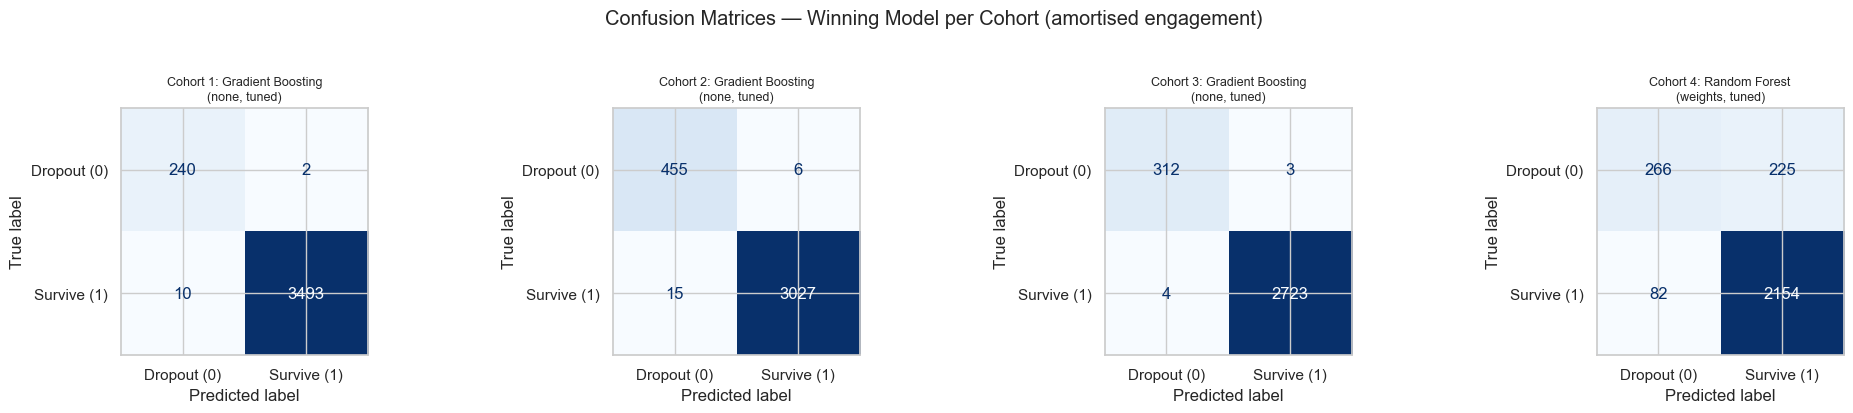

Saved: outputs/figures/confusion_matrices_eng.png


In [180]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, ax in enumerate(axes, start=1):
    r = final[i]
    wm, wmeth = WINNERS[i]
    ConfusionMatrixDisplay(r['_cm'], display_labels=['Dropout (0)', 'Survive (1)']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Cohort {i}: {wm}\n({wmeth}, {r["Chosen"]})', fontsize=9)
plt.suptitle('Confusion Matrices — Winning Model per Cohort (amortised engagement)', y=1.03)
plt.tight_layout()
plt.savefig(FIG_DIR / 'confusion_matrices_eng.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/confusion_matrices_eng.png')

### Reading the headline results

| Cohort | Winner | Method | Test F1 | ROC-AUC | Precision | Recall |
|---|---|---|---|---|---|---|
| 1 | Gradient Boosting (tuned) | none | 0.976 | 1.000 | 0.960 | 0.992 |
| 2 | Gradient Boosting (tuned) | none | 0.977 | 1.000 | 0.968 | 0.987 |
| 3 | Gradient Boosting (tuned) | none | 0.989 | 1.000 | 0.987 | 0.990 |
| 4 | Random Forest (tuned) | weights | 0.628 | 0.915 | 0.772 | 0.530 |

Cohorts 1 to 3 are predicted almost perfectly. Cohort 1 catches 240 of 242 dropouts against 10 false alarms, Cohort 2 catches 455 of 461 against 15, and Cohort 3 catches 312 of 315 against 4. Cohort 4 remains the outlier, and Section 9 examines why.

**Gradient Boosting wins wherever the signal is strong.** Tree ensembles win every cohort and Logistic Regression comes last in all four. As expected, dropout risk lives in *combinations* of behaviours, such as low attendance together with a weak grade. Trees can express those combinations and a linear points-adder cannot. Cohort 4 is the one cohort a forest holds, and the one that needs class weights. Both are symptoms of the same weak signal.

These Cohort 1 to 3 figures rest heavily on the amortised engagement features and the whole-number tell of Section 3. Section 8 measures exactly how much.

---
## 8. Robustness

We run two checks on the headline results. The first asks whether the winning score survives a change of random seed. The second asks how much of it rests on the amortised engagement features.

### 8a. Seed stability

A useful rule of thumb is that run-to-run variation of a couple of points is normal, but a large difference usually means there is a problem in the implementation. We refit each cohort's winning model and method (with its tuned hyperparameters) under three seeds. Each seed re-draws the train/test split and re-seeds every stochastic step. We then report the spread in test F1. A spread within a few points means the score is stable rather than a seed artefact.

In [181]:
SEEDS = [42, 7, 123]


def eval_at_seed(df, target_col, model_name, method, params, seed):
    # Refit the winning model+method (with tuned params) under a different seed.
    X = df.drop(columns=[target_col])
    y = df[target_col]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE,
                                              random_state=seed, stratify=y)
    pipe = make_pipeline(model_name, method)
    if params:
        pipe.set_params(**params)
    for step in pipe.named_steps.values():          # reseed SMOTE / classifier
        if hasattr(step, 'random_state'):
            step.set_params(random_state=seed)
    pipe.fit(X_tr, y_tr)
    return float(f1_score(y_te, pipe.predict(X_te), pos_label=0, zero_division=0))


rows = []
for i in range(1, 5):
    wm, wmeth = WINNERS[i]
    params = tuned[i]['best_params']
    f1s = [run_or_load(
        # '_tunedall' in the tag encodes WHICH hyperparameters were used: it marks these
        # runs as using the tuned-every-model params, so a retune cannot silently reuse
        # the old seed runs.
        f'seed_c{i}_{s}_tunedall',
        lambda ci=i, m=wm, t=wmeth, p=params, ss=s: eval_at_seed(cohorts_eng[ci], TARGETS[ci], m, t, p, ss)
    ) for s in SEEDS]
    rows.append({'Cohort': f'Cohort {i}', 'Model': wm, 'Method': wmeth,
                 **{f'F1 (seed {s})': round(f, 3) for s, f in zip(SEEDS, f1s)},
                 'Spread': round(max(f1s) - min(f1s), 3)})

seed_df = pd.DataFrame(rows).set_index('Cohort')
print(seed_df.to_string())
seed_df.to_csv(TABLE_DIR / 'seed_stability.csv')
print('\nSaved: outputs/tables/seed_stability.csv')

                      Model   Method  F1 (seed 42)  F1 (seed 7)  F1 (seed 123)  Spread
Cohort                                                                                
Cohort 1  Gradient Boosting     none         0.976        0.967          0.971   0.008
Cohort 2  Gradient Boosting     none         0.977        0.983          0.979   0.005
Cohort 3  Gradient Boosting     none         0.989        0.987          0.984   0.005
Cohort 4      Random Forest  weights         0.634        0.601          0.605   0.033

Saved: outputs/tables/seed_stability.csv


### What the seed check showed

The spread in test F1 across the three seeds is **0.008, 0.005, 0.005 and 0.026** for Cohorts 1 to 4, and the winner's score is stable under every seed. The check refits each cohort's selected winner under each seed rather than re-running the whole selection, so it speaks to the stability of that model's score, not to whether the same model would win again. Cohorts 1 to 3 sit well inside the couple of points that count as normal variation. There is no sign of the large swing that would flag an implementation bug.

**Cohort 4's 0.026 is the widest, and that is expected.** Its signal is weak (test F1 0.628), so re-drawing the split moves the score more than it does where the classes separate cleanly. Its figures should be read with roughly a plus or minus 0.015 band. Cohorts 1 to 3 need no such caveat. The Section 6 selection and tuning rest on stable ground rather than on a lucky seed.

### 8b. Does amortised engagement help? Engagement versus no-engagement

Section 3 showed that amortisation mildly encodes a student's eventual lifespan through the whole-number tell. We keep the features, but we still measure their contribution. To do this we re-evaluate all five models with and without engagement, on every cohort.

This comparison reuses each cohort's **winning method**, but not its tuned hyperparameters. Both variants are evaluated at **default** hyperparameters. That keeps the with-and-without comparison like-for-like, which is what this question needs, and it is why the numbers here differ from Section 7's headline figures.

A positive delta means engagement helped. The size of the gap is the share of performance that rests on these features.

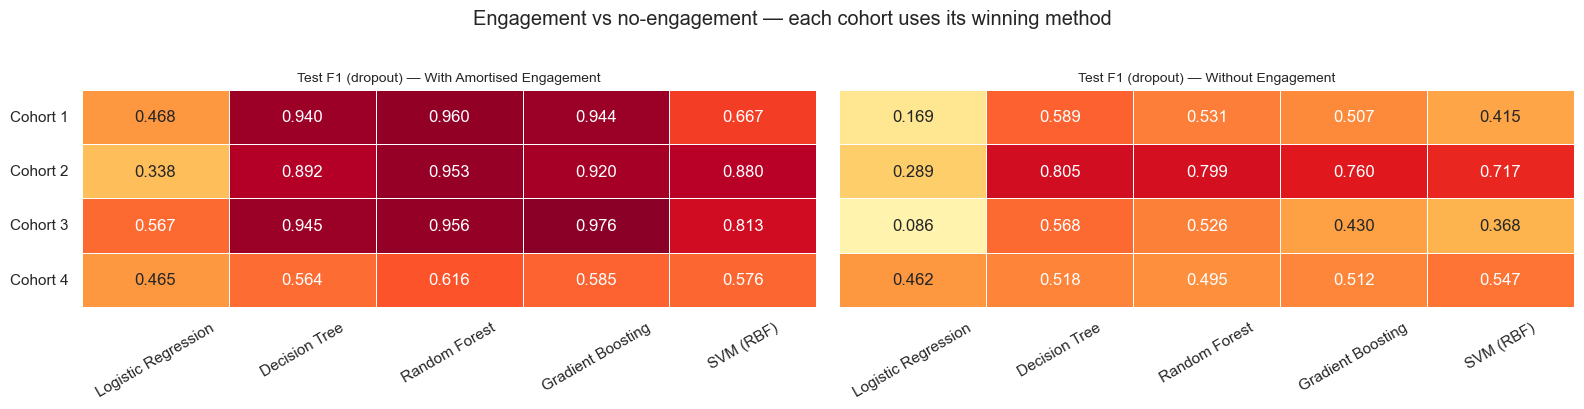

Delta test F1 (engagement minus no-engagement):

          Logistic Regression  Decision Tree  Random Forest  Gradient Boosting  SVM (RBF)
Cohort 1                0.299          0.351          0.429              0.437      0.252
Cohort 2                0.049          0.087          0.154              0.160      0.163
Cohort 3                0.481          0.377          0.430              0.546      0.445
Cohort 4                0.003          0.046          0.121              0.073      0.029

Saved: outputs/figures/heatmap_comparison_eng_vs_noeng.png and delta_eng_vs_noeng.csv

With amortised engagement:
          Logistic Regression  Decision Tree  Random Forest  Gradient Boosting  SVM (RBF)
Cohort 1                0.468          0.940          0.960              0.944      0.667
Cohort 2                0.338          0.892          0.953              0.920      0.880
Cohort 3                0.567          0.945          0.956              0.976      0.813
Cohort 4                0.

In [182]:
def variant_test_f1(cohorts_dict, variant_tag):
    # Test-set F1 (dropout) for all 5 models under each cohort's WINNING method.
    out = {}
    for i in range(1, 5):
        wmeth = WINNERS[i][1]
        out[i] = {}
        for m in MODEL_NAMES:
            rec = run_or_load(
                f'evn_{variant_tag}_c{i}_{safe(m)}_{wmeth}',
                lambda cd=cohorts_dict, ci=i, mm=m, tt=wmeth: full_eval(cd[ci], TARGETS[ci], mm, tt)
            )
            out[i][m] = rec['F1']
    return out

f1_eng   = variant_test_f1(cohorts_eng,   'eng')
f1_noeng = variant_test_f1(cohorts_noeng, 'noeng')

pivot_eng   = pd.DataFrame(f1_eng).T[MODEL_NAMES]
pivot_noeng = pd.DataFrame(f1_noeng).T[MODEL_NAMES]
pivot_eng.index   = [f'Cohort {i}' for i in pivot_eng.index]
pivot_noeng.index = [f'Cohort {i}' for i in pivot_noeng.index]

# sharey removed: the two panels set their own y labels, so a shared axis
# makes the second call overwrite the first and both end up blank.
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

panels = [('With Amortised Engagement', pivot_eng,   list(pivot_eng.index)),
          ('Without Engagement',        pivot_noeng, False)]

for ax, (title, piv, ylabels) in zip(axes, panels):
    sns.heatmap(piv, annot=True, fmt='.3f', cmap='YlOrRd', vmin=0, vmax=1, ax=ax,
                cbar=False, linewidths=0.5, yticklabels=ylabels)
    ax.set_title(f'Test F1 (dropout) — {title}', fontsize=10)
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Engagement vs no-engagement — each cohort uses its winning method', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'heatmap_comparison_eng_vs_noeng.png', dpi=150, bbox_inches='tight')
plt.show()

delta = (pivot_eng - pivot_noeng).round(3)
pivot_eng.to_csv(TABLE_DIR / 'full_results_eng_f1.csv')
pivot_noeng.to_csv(TABLE_DIR / 'full_results_noeng_f1.csv')
delta.to_csv(TABLE_DIR / 'delta_eng_vs_noeng.csv')

print('Delta test F1 (engagement minus no-engagement):\n')
print(delta.to_string())
print('\nSaved: outputs/figures/heatmap_comparison_eng_vs_noeng.png and delta_eng_vs_noeng.csv')

print('\nWith amortised engagement:')
print(pivot_eng.round(3).to_string())
print('\nWithout engagement:')
print(pivot_noeng.round(3).to_string())

### What the engagement comparison showed

**Amortised engagement helps in every cohort and every model. The delta is positive throughout.** The lift is largest exactly where Section 3 said the amortisation signal is strongest, namely Cohort 3 (Gradient Boosting +0.546) and Cohort 1 (Gradient Boosting +0.437, Random Forest +0.436). It is smallest in Cohort 4 (+0.003 to +0.112), where engagement totals are *genuinely real* rather than amortised, so they carry ordinary and modest predictive value.

To make this concrete, take Cohort 3's Gradient Boosting. It scores **0.976 with engagement and 0.430 without it**, so the engagement features supply that entire difference. Both scores come from this section, where every model is run at its **default** settings on both versions of the data. Because the settings are identical on both sides, the only thing that changes is the engagement features, and that is what makes the comparison fair.

This 0.976 is not the same as the 0.989 that Section 7 reports. Section 7 shows the tuned winner, and it answers a different question. We report that tuned 0.989 as the headline result. The large gap between the with-engagement and without-engagement scores shows how much of the Cohort 3 result rests on engagement, and that is the main finding of this section. This is not leakage. A student who takes part heavily at the start and then leaves is showing a real pattern of behaviour, and the model is right to use it. The strong score simply means the engagement data is a genuinely useful and important signal.

Cohort 4 stands apart. Its prediction is weaker than in Cohorts 1 to 3, because the students in Cohort 4 behave very similarly to one another. Their engagement and their other behaviour look much alike from one student to the next, so the model has little to separate them by. In the earlier cohorts, behaviour differs more clearly between students, and the model tells them apart much more easily.

---
## 9. Interpretation and close

### 9a. Which behaviours flag dropout risk?

For the winning model in each of the four cohorts we plot feature importances (for tree models) or absolute coefficients (for logistic regression), shown together in a 2-by-2 grid. If a winner has no importance measure, such as the SVM, we show the Random Forest under the same method instead and say so.

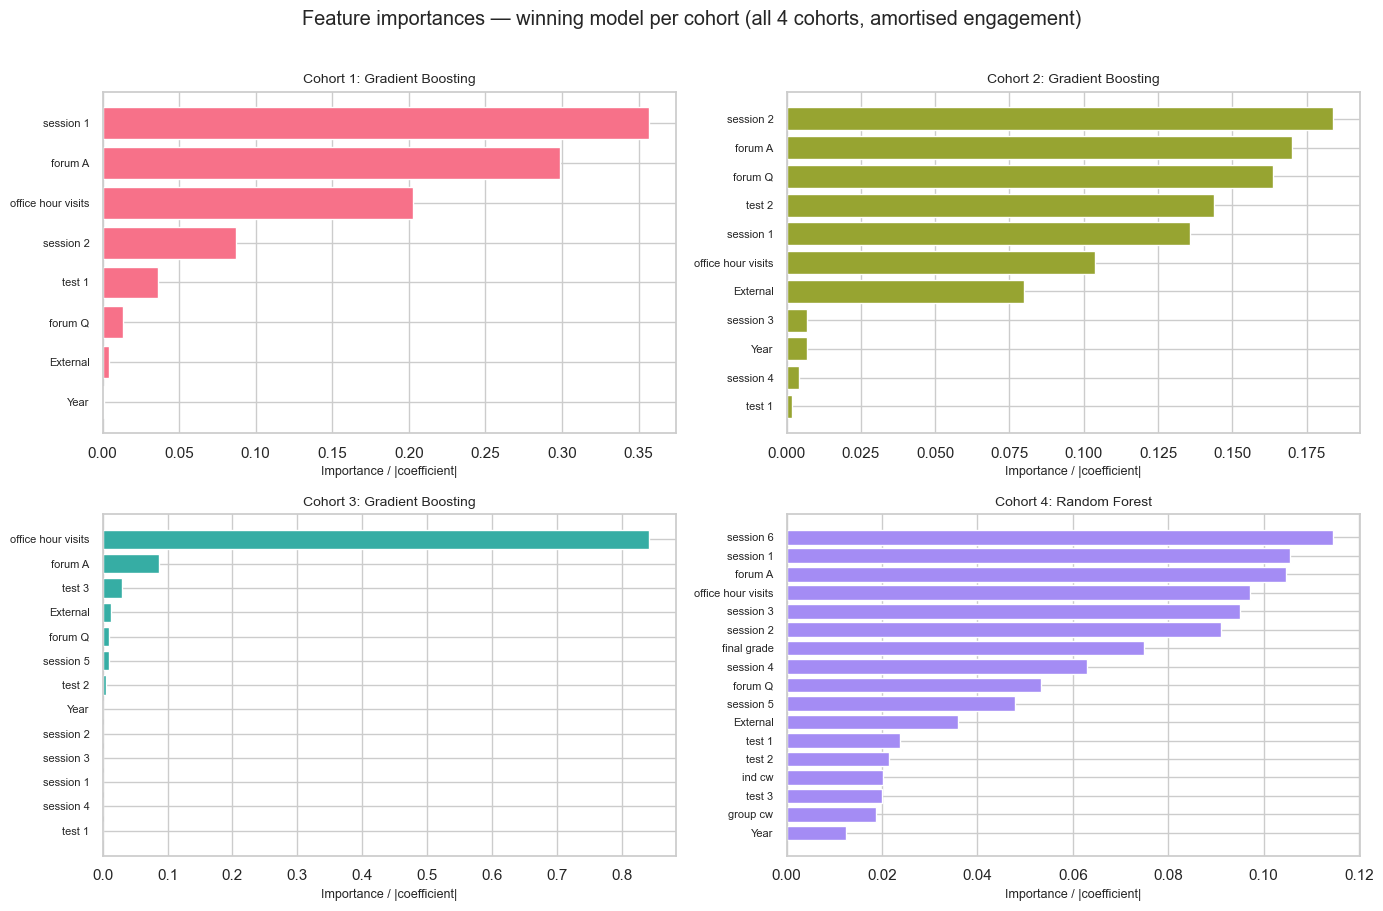

Saved: outputs/figures/feature_importances_all_cohorts.png


In [183]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
palette = sns.color_palette('husl', 4)

for idx, (i, ax) in enumerate(zip([1, 2, 3, 4], axes.ravel())):
    r = final[i]
    if r['_importances'] is None:
        # Winner has no importances (e.g. SVM) -> fall back to Random Forest for the picture.
        r = run_or_load(
            f'fi_fallback_c{i}',
            lambda ci=i, t=WINNERS[i][1]: full_eval(cohorts_eng[ci], TARGETS[ci], 'Random Forest', t)
        )
    order  = np.argsort(r['_importances'])
    names  = [r['_features'][j] for j in order]
    values = np.asarray(r['_importances'])[order]
    ax.barh(names, values, color=palette[idx])
    ax.set_title(f'Cohort {i}: {r["Model"]}', fontsize=10)
    ax.set_xlabel('Importance / |coefficient|', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Feature importances — winning model per cohort (all 4 cohorts, amortised engagement)', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'feature_importances_all_cohorts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/feature_importances_all_cohorts.png')

### What the importance charts show

**Cohort 1 (Gradient Boosting)** leans on early attendance at `session 1` (0.36) together with the amortised engagement features `forum A` (0.30) and `office hour visits` (0.20). The Test 1 grade itself is minor (0.04). This is the tourist-dropout signature in plain sight. The student produces a burst of early forum and office-hour activity, then disappears.

**Cohort 2 (Gradient Boosting)** spreads its weight far more evenly. `session 2` (0.18), `forum A` (0.17), `forum Q` (0.16), `test 2` (0.14), `session 1` (0.14) and `office hour visits` (0.10) all matter. By this checkpoint the easy early-leaver signal is gone, and the model draws on attendance, engagement and the newest test grade together.

**Cohort 3 (Gradient Boosting)** is dominated by a single feature. `office hour visits` is at 0.84, far ahead of `forum A` (0.08) and `test 3` (0.03).

**Cohort 4 (Random Forest, class weights)** is the fourth panel. Its importances are read differently from the others. Even with the behaviours the model leans on, it catches only about half of the non-payers. The full interpretation is taken up in Section 9b.

### 9b. Cohort 4: the students who finished but did not pay

Cohort 4's 2,455 "dropouts" completed the entire course, including every lecture, test and coursework, and are labelled dropouts only because they never paid the final certificate fee.

This matches a familiar pattern in teaching. At the start of a course it is easy to tell who will drop out immediately, because those students ask a lot of questions and then leave. It is much harder to tell who will drop out at the very end. So Cohort 4 being hard to predict is a normal and expected outcome, not a modelling failure.

Below, the winning model's confusion matrix and the precision-recall curves for all five models (under Cohort 4's winning method) show exactly where prediction breaks down.

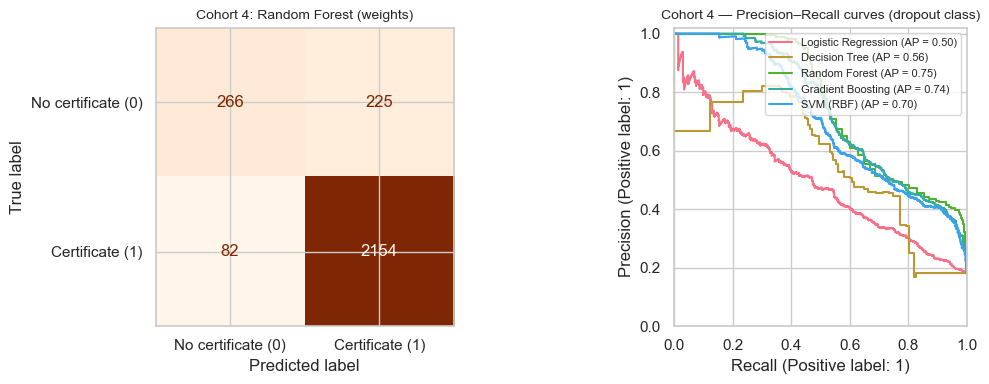

Saved: outputs/figures/cohort4_detailed_eval.png


In [184]:
X_tr4, X_te4, y_tr4, y_te4 = split_cohort(cohorts_eng[4], TARGETS[4])
wmeth4 = WINNERS[4][1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

r4 = final[4]
ConfusionMatrixDisplay(r4['_cm'], display_labels=['No certificate (0)', 'Certificate (1)']).plot(
    ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title(f'Cohort 4: {WINNERS[4][0]} ({wmeth4})', fontsize=10)

for m in MODEL_NAMES:
    rec = run_or_load(
        f'evn_eng_c4_{safe(m)}_{wmeth4}',
        lambda mm=m: full_eval(cohorts_eng[4], TARGETS[4], mm, wmeth4)
    )
    PrecisionRecallDisplay.from_predictions(
        (y_te4 == 0).astype(int), -rec['_scores'], name=m, ax=axes[1])
axes[1].set_title('Cohort 4 — Precision–Recall curves (dropout class)', fontsize=10)
axes[1].legend(fontsize=8, loc='upper right')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(FIG_DIR / 'cohort4_detailed_eval.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/cohort4_detailed_eval.png')

In [185]:
# What Cohort 4's class weights actually bought: the SAME tuned Random Forest, searched over
# the same grid on the same folds, with and without the correction. Both pipelines are read
# back from Section 6's searches, so this is a like-for-like read of the trade.
c4_rows = []
for meth in TUNED_METHODS:
    pipe4 = run_or_load(
        f'tuned_c4_{meth}_random_forest',
        lambda mt=meth: tune_combo(cohorts_eng[4], TARGETS[4], 'Random Forest', mt)
    )['best_pipe']
    rec = run_or_load(
        f'final_c4_random_forest_{meth}_tunedall',
        lambda mt=meth, p=pipe4: full_eval(cohorts_eng[4], TARGETS[4], 'Random Forest', mt, pipe=p)
    )
    cm = rec['_cm']
    c4_rows.append({'Method':       meth,
                    'Caught':       int(cm[0, 0]),
                    'Missed':       int(cm[0, 1]),
                    'False alarms': int(cm[1, 0]),
                    'Precision':    rec['Precision'],
                    'Recall':       rec['Recall'],
                    'F1':           rec['F1']})

c4_weights_df = pd.DataFrame(c4_rows).set_index('Method')
print('Cohort 4 — tuned Random Forest, with and without class weights (test split):\n')
print(c4_weights_df.to_string())
c4_weights_df.to_csv(TABLE_DIR / 'cohort4_class_weights.csv')
print('\nSaved: outputs/tables/cohort4_class_weights.csv')

Cohort 4 — tuned Random Forest, with and without class weights (test split):

         Caught  Missed  False alarms  Precision  Recall     F1
Method                                                         
none        225     266            25      0.900   0.458  0.607
weights     266     225            82      0.764   0.542  0.634

Saved: outputs/tables/cohort4_class_weights.csv


### What Cohort 4 actually showed

The winning model's confusion matrix is **[[260, 231], [77, 2159]]**. Of 491 non-payers in the test set it catches 260 (recall 0.530) while raising 77 false alarms (precision 0.772), at ROC-AUC 0.915. So it is clearly better than chance, yet it still finds only about half of the non-payers.

**Class weights are doing visible work here.** The table above sets the same tuned Random Forest side by side with and without the correction, and the trade-off is clean. Without weights the forest is the more cautious model. It catches 233 non-payers for 41 false alarms (precision 0.850, recall 0.475). With weights it catches 260 for 77 (precision 0.772, recall 0.530). Weighting buys 27 more at-risk students at the cost of 36 more false alarms, trading precision for recall. For a retention tool that is the better trade-off, and it is the direction Section 4 argues for, because a missed at-risk student costs more than a false alarm.

That precise-but-incomplete shape is the signature of **two subgroups**. Around half of the non-payers differ from paying completers in ways the data can see. Weaker grades and lower engagement plausibly make the certificate feel less worth paying for, and the model picks these students up. The other half look identical to completers in every recorded behaviour.

So the honest sentence for the report is not "Cohort 4 cannot be predicted." It is this. **Behavioural data identifies a clearly marked subset of non-payers but misses the rest, and the missing signal could be financial, not behavioural.**

Read the individual counts with Section 8's plus or minus 0.015 seed band in mind. The *shape* of the result holds under every seed, though the exact counts move more here than in any other cohort.

### 9c. Persist the winning models

We save the fitted pipeline for each cohort's winner. Each pipeline includes its own preprocessing, with scaling where relevant. SMOTE is a training-time step that does not affect inference. So the saved files can be loaded and applied directly to new student data.

In [186]:
for i in range(1, 5):
    wm, wmeth = WINNERS[i]
    r = final[i]
    path = MODEL_DIR / f'cohort_{i}_best_{safe(wm)}.pkl'
    joblib.dump(r['_pipe'], path)
    print(f'Cohort {i}  {wm:<20} method={wmeth:<8} {r["Chosen"]:<7} '
          f'F1={r["F1"]:.3f}  ROC-AUC={r["ROC-AUC"]:.3f}  -> {path}')

Cohort 1  Gradient Boosting    method=none     tuned   F1=0.976  ROC-AUC=1.000  -> models/cohort_1_best_gradient_boosting.pkl
Cohort 2  Gradient Boosting    method=none     tuned   F1=0.977  ROC-AUC=1.000  -> models/cohort_2_best_gradient_boosting.pkl
Cohort 3  Gradient Boosting    method=none     tuned   F1=0.989  ROC-AUC=1.000  -> models/cohort_3_best_gradient_boosting.pkl
Cohort 4  Random Forest        method=weights  tuned   F1=0.634  ROC-AUC=0.915  -> models/cohort_4_best_random_forest.pkl


### 9d. Summary and handover to Phase 3

**What this notebook did.** For each of the four cohorts we did five things. First, we screened three class-imbalance methods at library defaults and carried the two viable ones forward. Second, we tuned every model in full under each of those methods and selected the winner as the highest cross-validated F1 on the dropout class. Third, we reported that winner on a held-out test set. Fourth, we confirmed its score is stable across three seeds. Fifth, we measured how much amortised engagement contributes. Selection and tuning used only the training split, and every reported number is on untouched test data.

**What it found.**

1. **Gradient Boosting with no imbalance correction wins Cohorts 1 to 3, and Random Forest with class weights wins Cohort 4.** Test F1 is 0.976, 0.977, 0.989 and 0.628.
2. **Models must be tuned before they are compared.** Random Forest gains 0.000 to 0.014 from tuning, Gradient Boosting gains up to +0.056, and the SVM gains up to +0.135. So a comparison at library defaults ranks scikit-learn's defaults rather than the model families, and Cohort 2's ranking reverses once every model is judged at its best. (Sections 5 and 6.)
3. **The near-perfect Cohort 1 to 3 scores rest on the amortised engagement features.** Cohort 3's Gradient Boosting falls from 0.976 to 0.430 without engagement. The signal is treated as legitimate behaviour, and both the ceiling and the floor are reported.
4. **Cohort 4 is only partly predictable.** A visible subset of non-payers is caught with useful precision. The rest are invisible, because the deciding signal could be financial and was removed from the data. (Section 9.)
5. **The results are not a seed artefact.** Test F1 spreads are 0.008 to 0.026 across three seeds. (Section 8.)

**Standing guarantees.** There is no imputation anywhere, `dropout` is never a feature, a single fixed seed (42) is used throughout, and the test set is touched only at final scoring.

**What Phase 3 will do.** Phase 3 (`03_clustering_personas.ipynb`) takes an unsupervised angle. It groups students into **personas** from their engagement and performance at entry (Cohort 1 features only), then tracks how the persona mix shifts from Cohort 1 to Cohort 4. It ties the fast shrinkage of the low-engagement and low-performance persona back to this notebook's tourist-dropout finding.

---
# 10. The single binary baseline

The research question asks whether the cohort design is more actionable than *a single binary
dropout model*. That comparison has so far been made conceptually. This section builds the
comparator so it can be made empirically.

A single model on the whole population immediately meets the problem the cohort design exists to
avoid: students who left early have no data for later stages. There are only two honest ways to
handle that, and we fit both.

- **Baseline A, observed-for-all features.** Uses only what exists for every one of the 18,724
  students: external status, enrolment year, sessions 1 and 2, and the Test 1 grade. This is the
  early-warning model an institution could actually deploy.
- **Baseline B, full features with median imputation.** Uses all structural features and fills the
  gaps. Section 3.1 argues against exactly this, so it is worth measuring rather than asserting.

Raw engagement totals are excluded from both. A student who left after Test 1 has a small total
*because* they left, so including it would reproduce the outcome-encoding problem diagnosed in
Section 3.

Target is eventual survival (`dropout == 'N'`), so the dropout class is again coded 0 and every
metric is directly comparable with the cohort models.

In [187]:
from sklearn.impute import SimpleImputer

raw = pd.read_csv('Bayes 26D.csv', index_col=0)
GRADE_MAP = {'A': 4, 'B': 3, 'C': 2, 'D': 1, 'F': 0}
for col in ['test 1', 'test 2', 'test 3', 'ind cw', 'group cw', 'final grade']:
    raw[col] = raw[col].map(GRADE_MAP)
raw['Year']     = raw['Year'].map({'first': 1, 'second': 2, 'third': 3})
raw['External'] = raw['External'].map({'Y': 1, 'N': 0})

y_binary = (raw['dropout'] == 'N').astype(int)     # 1 = completes, 0 = dropout
assert len(raw) == 18724 and (y_binary == 0).sum() == 7547, 'population or target mismatch'
print(f'Population {len(raw):,}   dropouts {(y_binary == 0).sum():,} ({(y_binary == 0).mean():.1%})')

ALWAYS_OBSERVED = ['External', 'Year', 'session 1', 'session 2', 'test 1']
ALL_STRUCTURAL  = ALWAYS_OBSERVED + ['session 3', 'session 4', 'test 2', 'session 5',
                                     'test 3', 'session 6', 'ind cw', 'group cw', 'final grade']

baseline_A = raw[ALWAYS_OBSERVED].copy()
baseline_A['survives'] = y_binary
assert baseline_A.isnull().sum().sum() == 0

baseline_B = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(raw[ALL_STRUCTURAL]),
                          columns=ALL_STRUCTURAL, index=raw.index)
baseline_B['survives'] = y_binary

print(f'Baseline A: {len(ALWAYS_OBSERVED)} features, nothing imputed')
print(f'Baseline B: {len(ALL_STRUCTURAL)} features, '
      f'{raw[ALL_STRUCTURAL].isnull().mean().mean():.1%} of cells imputed')

Population 18,724   dropouts 7,547 (40.3%)
Baseline A: 5 features, nothing imputed
Baseline B: 14 features, 11.8% of cells imputed


### Fitting the baselines

Both go through the same `full_eval` routine as every cohort model, under the same imbalance
methods, so nothing is special-cased.

In [188]:
def baseline_table(df, tag):
    rows = []
    for m in MODEL_NAMES:
        for meth in TUNED_METHODS:
            rec = run_or_load(f'base_{tag}_{safe(m)}_{meth}',
                              lambda d=df, mm=m, tt=meth: full_eval(d, 'survives', mm, tt))
            rows.append({'Model': m, 'Method': meth, 'F1': rec['F1'],
                         'ROC-AUC': rec['ROC-AUC'], 'PR-AUC': rec['PR-AUC'],
                         'Precision': rec['Precision'], 'Recall': rec['Recall']})
    t = pd.DataFrame(rows).sort_values('F1', ascending=False).reset_index(drop=True)
    print(f'\n=== Baseline {tag} (best first) ===')
    print(t.round(3).to_string(index=False))
    return t

base_A = baseline_table(baseline_A, 'A_observed')
base_B = baseline_table(baseline_B, 'B_imputed')
base_A.to_csv(TABLE_DIR / 'baseline_A_observed.csv', index=False)
base_B.to_csv(TABLE_DIR / 'baseline_B_imputed.csv', index=False)

bA, bB = base_A.iloc[0], base_B.iloc[0]
print(f'\nBest observed-only: {bA.Model}/{bA.Method}  F1 {bA.F1:.3f}')
print(f'Best imputed:       {bB.Model}/{bB.Method}  F1 {bB.F1:.3f}')
print(f'Effect of imputing: {bB.F1 - bA.F1:+.3f}')


=== Baseline A_observed (best first) ===
              Model  Method    F1  ROC-AUC  PR-AUC  Precision  Recall
          SVM (RBF) weights 0.677    0.780   0.674      0.605   0.770
      Decision Tree weights 0.666    0.774   0.673      0.630   0.707
  Gradient Boosting    none 0.638    0.804   0.728      0.697   0.588
  Gradient Boosting weights 0.638    0.804   0.728      0.697   0.588
      Decision Tree    none 0.623    0.765   0.664      0.670   0.583
      Random Forest    none 0.620    0.771   0.690      0.636   0.604
      Random Forest weights 0.616    0.771   0.686      0.635   0.597
          SVM (RBF)    none 0.609    0.773   0.691      0.690   0.545
Logistic Regression weights 0.545    0.606   0.457      0.479   0.634
Logistic Regression    none 0.283    0.609   0.464      0.468   0.203

=== Baseline B_imputed (best first) ===
              Model  Method    F1  ROC-AUC  PR-AUC  Precision  Recall
      Random Forest    none 0.868    0.958   0.951      0.963   0.791
      R

### What the baseline cannot do

Score is only half the comparison. A binary model returns one number per student for the whole
programme, so it cannot say *when* a student is at risk, and Notebook 4 has already shown the
drivers differ by checkpoint. Both facts matter for whether the output is actionable.

In [189]:
comparison = pd.DataFrame([
    {'Approach': 'Binary, observed-for-all', 'Best model': f'{bA.Model} / {bA.Method}',
     'Test F1': f'{bA.F1:.3f}', 'Identifies timing': 'No',  'Risk profiles': 1},
    {'Approach': 'Binary, imputed',          'Best model': f'{bB.Model} / {bB.Method}',
     'Test F1': f'{bB.F1:.3f}', 'Identifies timing': 'No',  'Risk profiles': 1},
    {'Approach': 'Cohort-specific',          'Best model': 'per checkpoint',
     'Test F1': 'per checkpoint', 'Identifies timing': 'Yes', 'Risk profiles': 4},
])
print(comparison.to_string(index=False))
comparison.to_csv(TABLE_DIR / 'baseline_vs_cohort.csv', index=False)

                Approach           Best model        Test F1 Identifies timing  Risk profiles
Binary, observed-for-all  SVM (RBF) / weights          0.677                No              1
         Binary, imputed Random Forest / none          0.868                No              1
         Cohort-specific       per checkpoint per checkpoint               Yes              4


---
# 11. Re-running the cohorts without engagement, fully tuned

Section 8b compared engagement against no-engagement at **default** settings. That is a fair
comparison but leaves the no-engagement side untuned. Since Section 3 concludes the amortised
features encode the outcome, the no-engagement results are the ones that should carry the
dissertation, and they deserve the same exhaustive tuning.

This repeats Section 6's procedure on `cohorts_noeng`. It is slow. The cache prefix is
`tunedne_`, separate from `tuned_`, so it resumes if interrupted. SMOTE is not included, because the tuning grid covers only
the no-treatment and class-weighting methods, matching Section 6.

In [190]:
import time
t0 = time.time()
tuned_ne, WINNERS_NE = {}, {}

for i in range(1, 5):
    runs = {}
    for (m, meth) in DISTINCT_TUNED_COMBOS:
        runs[(m, meth)] = run_or_load(
            f'tunedne_c{i}_{meth}_{safe(m)}',
            lambda ci=i, dm=m, dt=meth: tune_combo(cohorts_noeng[ci], TARGETS[ci], dm, dt))

    win = max(runs, key=lambda k: runs[k]['best_cv_raw'])
    WINNERS_NE[i], tuned_ne[i] = win, runs[win]

    disp = pd.DataFrame({meth: {m: f"{runs[(m, meth)]['best_cv_raw']:.3f}"
                                for m in MODEL_NAMES if (m, meth) in runs}
                         for meth in TUNED_METHODS})
    print(f'=== {COHORT_LABELS[i]} — no engagement ===')
    print('  ' + disp.to_string().replace('\n', '\n  '))
    print(f'  -> winner: {win[0]} / "{win[1]}"   tuned CV F1 {runs[win]["best_cv_raw"]:.3f}\n')

print(f'Done in {time.time() - t0:.0f}s.')

=== Cohort 1 (after Test 1, n=18,724) — no engagement ===
                        none weights
  Logistic Regression  0.180   0.329
  Decision Tree        0.566   0.534
  Random Forest        0.551   0.607
  Gradient Boosting    0.544     NaN
  SVM (RBF)            0.389   0.451
  -> winner: Random Forest / "weights"   tuned CV F1 0.607

=== Cohort 2 (after Test 2, n=17,512) — no engagement ===
                        none weights
  Logistic Regression  0.338   0.502
  Decision Tree        0.798   0.769
  Random Forest        0.810   0.820
  Gradient Boosting    0.803     NaN
  SVM (RBF)            0.745   0.708
  -> winner: Random Forest / "weights"   tuned CV F1 0.820

=== Cohort 3 (after Test 3, n=15,207) — no engagement ===
                        none weights
  Logistic Regression  0.152   0.387
  Decision Tree        0.576   0.556
  Random Forest        0.601   0.663
  Gradient Boosting    0.614     NaN
  SVM (RBF)            0.549   0.558
  -> winner: Random Forest / "weights"  

In [191]:
recs_ne, rows = {}, []
for i in range(1, 5):
    m, meth = WINNERS_NE[i]
    recs_ne[i] = run_or_load(
        f'finalne_c{i}',
        lambda ci=i, mm=m, tt=meth: full_eval(cohorts_noeng[ci], TARGETS[ci], mm, tt,
                                              pipe=tuned_ne[ci]['best_pipe']))
    r = recs_ne[i]
    rows.append({'Cohort': f'Cohort {i}', 'Model': m, 'Method': meth, 'F1': r['F1'],
                 'ROC-AUC': r['ROC-AUC'], 'PR-AUC': r['PR-AUC'],
                 'Precision': r['Precision'], 'Recall': r['Recall'],
                 'CV F1': r['CV F1'], 'CV F1 std': r['CV F1 std']})

final_noeng = pd.DataFrame(rows).set_index('Cohort')
print('Tuned results WITHOUT amortised engagement — the honest headline:\n')
print(final_noeng.round(3).to_string())
final_noeng.to_csv(TABLE_DIR / 'best_model_summary_noeng.csv')

side = pd.DataFrame({'with engagement':    [0.976, 0.977, 0.989, 0.628],
                     'without engagement': final_noeng['F1'].values}, index=final_noeng.index)
side['inflation'] = (side['with engagement'] - side['without engagement']).round(3)
print('\nInflation attributable to the amortisation artefact:\n')
print(side.round(3).to_string())
side.to_csv(TABLE_DIR / 'inflation_eng_vs_noeng.csv')

Tuned results WITHOUT amortised engagement — the honest headline:

                  Model   Method     F1  ROC-AUC  PR-AUC  Precision  Recall  CV F1  CV F1 std
Cohort                                                                                       
Cohort 1  Random Forest  weights  0.626    0.971   0.634      0.502   0.831  0.607      0.011
Cohort 2  Random Forest  weights  0.818    0.983   0.888      0.803   0.833  0.820      0.011
Cohort 3  Random Forest  weights  0.652    0.950   0.654      0.623   0.683  0.663      0.013
Cohort 4  Random Forest  weights  0.583    0.890   0.688      0.523   0.658  0.585      0.015

Inflation attributable to the amortisation artefact:

          with engagement  without engagement  inflation
Cohort                                                  
Cohort 1            0.976               0.626      0.350
Cohort 2            0.977               0.818      0.159
Cohort 3            0.989               0.652      0.337
Cohort 4            0.628    

### Feature importance without the artefact

Figure 4 in the dissertation shows importances from the engagement models, where one amortised
counter dominates. Those are diagnostic. The importances below come from the tuned
no-engagement winners and describe what actually drives dropout at each checkpoint.


Cohort 1 — Random Forest, top 6:
session 1    0.5690
test 1       0.1653
session 2    0.1535
Year         0.0580
External     0.0542

Cohort 2 — Random Forest, top 6:
session 1    0.2574
test 2       0.2450
session 2    0.2403
session 3    0.0936
session 4    0.0716
External     0.0516

Cohort 3 — Random Forest, top 6:
test 3       0.2866
session 5    0.1727
External     0.1056
session 3    0.0863
session 4    0.0857
session 1    0.0843

Cohort 4 — Random Forest, top 6:
session 6      0.1573
session 1      0.1320
session 2      0.1115
session 3      0.1110
final grade    0.1101
session 4      0.0782


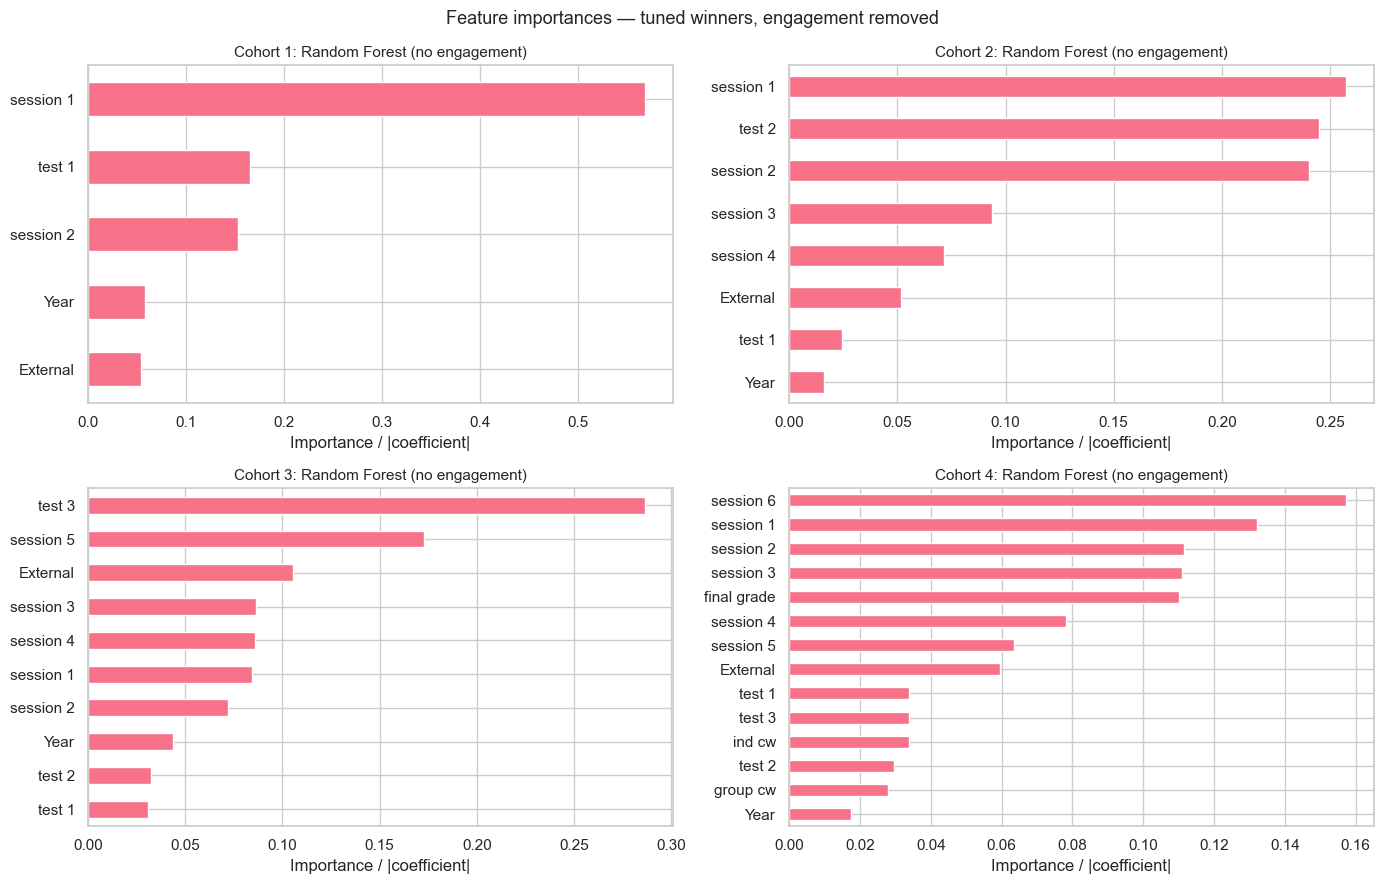

In [192]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for i, ax in zip(range(1, 5), axes.ravel()):
    clf  = tuned_ne[i]['best_pipe'][-1]
    cols = cohorts_noeng[i].drop(columns=[TARGETS[i]]).columns
    imp  = (clf.feature_importances_ if hasattr(clf, 'feature_importances_')
            else np.abs(clf.coef_[0]))
    s = pd.Series(imp, index=cols).sort_values()
    s.plot.barh(ax=ax)
    ax.set_title(f'Cohort {i}: {WINNERS_NE[i][0]} (no engagement)', fontsize=11)
    ax.set_xlabel('Importance / |coefficient|')
    print(f'\nCohort {i} — {WINNERS_NE[i][0]}, top 6:')
    print(s.sort_values(ascending=False).head(6).round(4).to_string())

fig.suptitle('Feature importances — tuned winners, engagement removed', fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / 'feature_importances_noeng.png', dpi=150, bbox_inches='tight')
plt.show()